<a href="https://colab.research.google.com/github/rikesh28/Credit_Card_Fraud_Detection/blob/main/notebooks/2)%20pattern_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
transaction_data = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Raw Data/train_transaction.csv.zip')
transaction_data.head()

## Transaction amount patterns

From EDA, amounts didn't look very different between fraud/legit. Let's look more carefully with different plot types.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

# cap at 500 to see the bulk of the distribution
subset = transaction_data[transaction_data['TransactionAmt'] < 500]

sns.kdeplot(data=subset, x='TransactionAmt', hue='isFraud', fill=True, alpha=0.2, ax=axes[0])
axes[0].set_title('KDE - Transaction Amount')

sns.boxplot(data=subset, x='isFraud', y='TransactionAmt', ax=axes[1])
axes[1].set_xticklabels(['Not Fraud', 'Fraud'])

sns.violinplot(data=subset, x='isFraud', y='TransactionAmt', ax=axes[2])
axes[2].set_xticklabels(['Not Fraud', 'Fraud'])

sns.stripplot(data=subset.sample(n=5000, random_state=42), x='isFraud', y='TransactionAmt', ax=axes[3])
axes[3].set_xticklabels(['Not Fraud', 'Fraud'])

plt.tight_layout()
plt.show()

# confirmed: distributions are very similar. amount alone won't be a strong predictor.
print('Amount stats by fraud label:')
transaction_data.groupby('isFraud')['TransactionAmt'].describe()

## Product and card type breakdown

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

fraud_by_product = transaction_data.groupby('ProductCD')['isFraud'].agg(['mean', 'count'])
fraud_by_product['Fraud_rate'] = fraud_by_product['mean'] * 100

sns.barplot(data=fraud_by_product, x='ProductCD', y='Fraud_rate', ax=axes[0])
axes[0].set_title('Fraud Rate by Product')

# annotate with sample counts
for i, row in fraud_by_product.iterrows():
    axes[0].text(i, row['Fraud_rate'] + 0.1, f'n={row["count"]:,}', ha='center', fontsize=9)

sns.countplot(data=transaction_data, x='ProductCD', hue='isFraud', ax=axes[1])
axes[1].set_title('Transaction Count by Product')

plt.tight_layout()
plt.show()

# Product W dominates the dataset (440k txns) but has the lowest fraud rate (2%).
# Product C is only 68k txns but 11.7% fraud - definitely a useful feature.

## Card type analysis

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# card4 = card brand, card6 = credit vs debit
for i, (col, title) in enumerate([('card4', 'Card Brand'), ('card6', 'Card Category')]):
    card_fraud = transaction_data.groupby(col)['isFraud'].agg(['mean', 'count']).reset_index()
    card_fraud = card_fraud[card_fraud['count'] > 1000]  # drop tiny groups
    card_fraud['fraud_rate'] = card_fraud['mean'] * 100
    sns.barplot(data=card_fraud, x=col, y='fraud_rate', ax=axes[i])
    axes[i].set_title(f'Fraud Rate by {title}')
    axes[i].set_ylabel('Fraud Rate (%)')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Email domain analysis

Curious whether certain email providers are associated with more fraud.

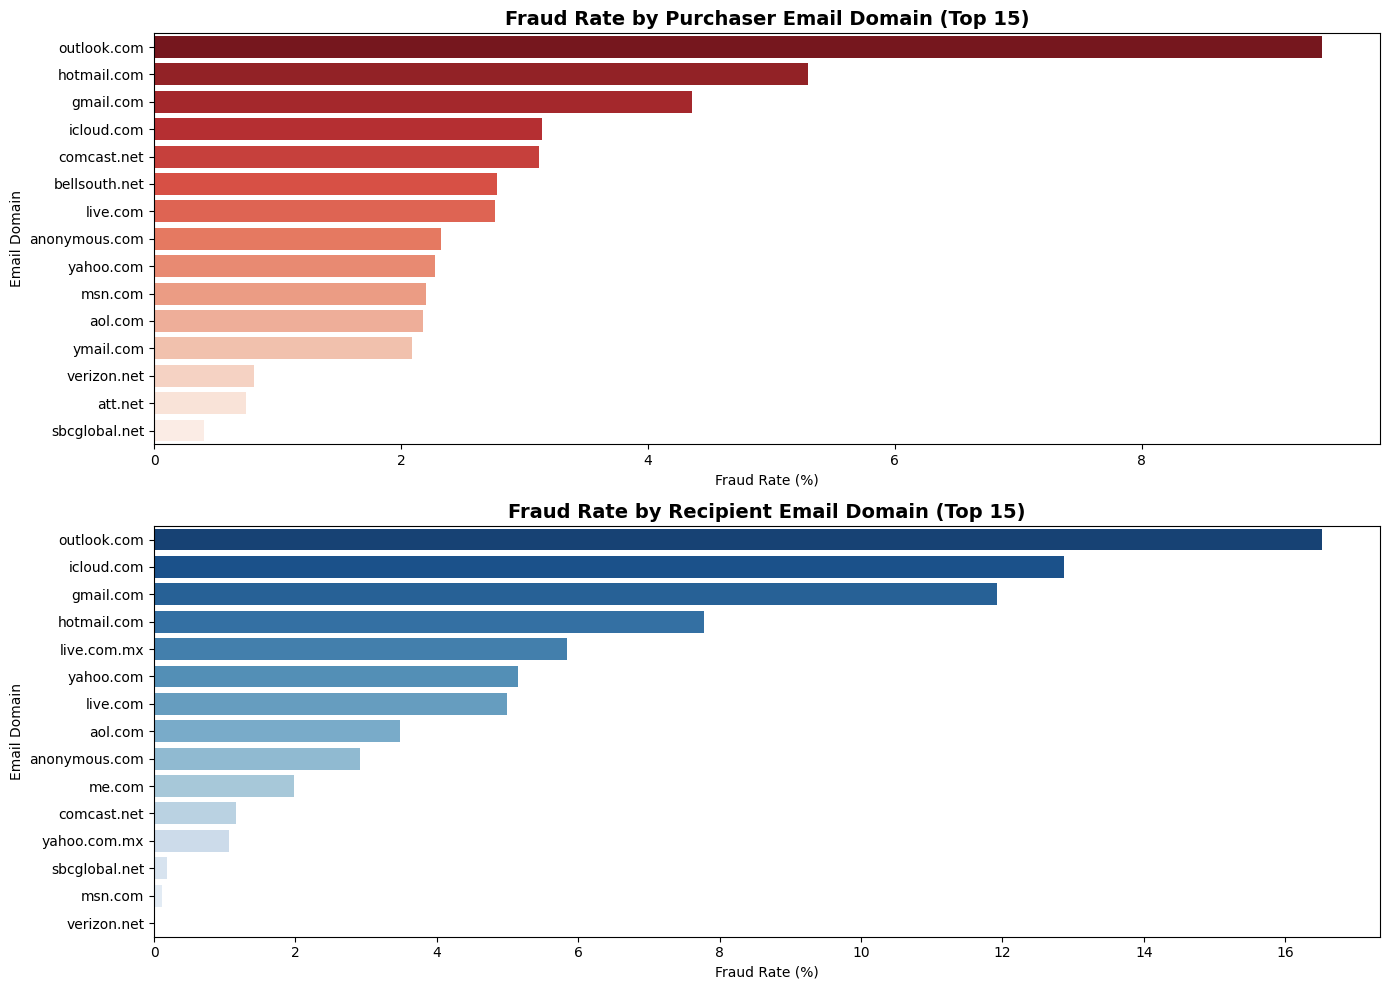

In [ ]:
fig, axes = plt.subplots(2,1, figsize=(14, 10))

# P_emaildomain (Purchaser email)
top_p_domains = transaction_data['P_emaildomain'].value_counts().head(15).index
p_domain_data = transaction_data[transaction_data['P_emaildomain'].isin(top_p_domains)]
p_fraud_rate = p_domain_data.groupby('P_emaildomain')['isFraud'].mean().sort_values(ascending=False).reset_index()
p_fraud_rate['fraud_rate'] = p_fraud_rate['isFraud'] * 100

sns.barplot(data=p_fraud_rate,
            x='fraud_rate',
            y='P_emaildomain',
            ax=axes[0],
            palette='Reds_r')
axes[0].set_title('Fraud Rate by Purchaser Email Domain (Top 15)', )
axes[0].set_xlabel('Fraud Rate (%)')
axes[0].set_ylabel('Email Domain')

# R_emaildomain (Recipient email)
top_r_domains = transaction_data['R_emaildomain'].value_counts().head(15).index
r_domain_data = transaction_data[transaction_data['R_emaildomain'].isin(top_r_domains)]
r_fraud_rate = r_domain_data.groupby('R_emaildomain')['isFraud'].mean().sort_values(ascending=False).reset_index()
r_fraud_rate['fraud_rate'] = r_fraud_rate['isFraud'] * 100

sns.barplot(data=r_fraud_rate,
            x='fraud_rate',
            y='R_emaildomain',
            ax=axes[1],
            palette='Blues_r')
axes[1].set_title('Fraud Rate by Recipient Email Domain (Top 15)', )
axes[1].set_xlabel('Fraud Rate (%)')
axes[1].set_ylabel('Email Domain')

plt.tight_layout()
plt.show()

## Time-based patterns

TransactionDT is seconds from some reference time. Let's extract hour/day and see if fraud has time-of-day patterns.

In [ ]:
transaction_data['hour'] = (transaction_data['TransactionDT'] // 3600) % 24
transaction_data['day'] = (transaction_data['TransactionDT'] // (3600 * 24))
transaction_data['day_of_week'] = transaction_data['day'] % 7

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# fraud rate peaks early morning - makes sense, less monitoring + automated attacks
hourly_fraud = transaction_data.groupby('hour')['isFraud'].mean() * 100
axes[0, 0].plot(hourly_fraud.index, hourly_fraud.values, marker='o', color='crimson')
axes[0, 0].set_title('Fraud Rate by Hour')
axes[0, 0].set_xlabel('Hour')
axes[0, 0].set_ylabel('Fraud Rate (%)')
axes[0, 0].grid(True, alpha=0.3)

# legitimate txns peak during business hours, fraud peaks off-hours
hourly_count = transaction_data.groupby(['hour', 'isFraud']).size().reset_index(name='count')
sns.lineplot(data=hourly_count, x='hour', y='count', hue='isFraud', marker='o', ax=axes[0, 1])
axes[0, 1].set_title('Transaction Volume by Hour')
axes[0, 1].legend(title='Fraud', labels=['Legit', 'Fraud'])

dow_fraud = transaction_data.groupby('day_of_week')['isFraud'].mean() * 100
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
sns.barplot(x=list(range(7)), y=dow_fraud.values, ax=axes[1, 0])
axes[1, 0].set_title('Fraud Rate by Day of Week')
axes[1, 0].set_xticklabels(dow_labels)
axes[1, 0].set_ylabel('Fraud Rate (%)')

daily_fraud = transaction_data.groupby('day')['isFraud'].mean() * 100
axes[1, 1].plot(daily_fraud.index, daily_fraud.values, color='darkgreen', linewidth=1)
axes[1, 1].set_title('Daily Fraud Rate Over Time')
axes[1, 1].set_xlabel('Day')
axes[1, 1].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.show()

## Missing data & correlations

In [ ]:
missing_data = ((transaction_data.isnull().sum() / len(transaction_data)) * 100).sort_values(ascending=False)
missing_data = missing_data[missing_data > 0].head(30)

plt.figure(figsize=(12, 6))
sns.barplot(x=missing_data.values, y=missing_data.index)
plt.title('Top 30 Features by % Missing')
plt.xlabel('% Missing')
plt.show()

# dist2 is >90% missing - probably should just drop it. dist1 is ~60% missing.
# lots of the V features have high missingness too.

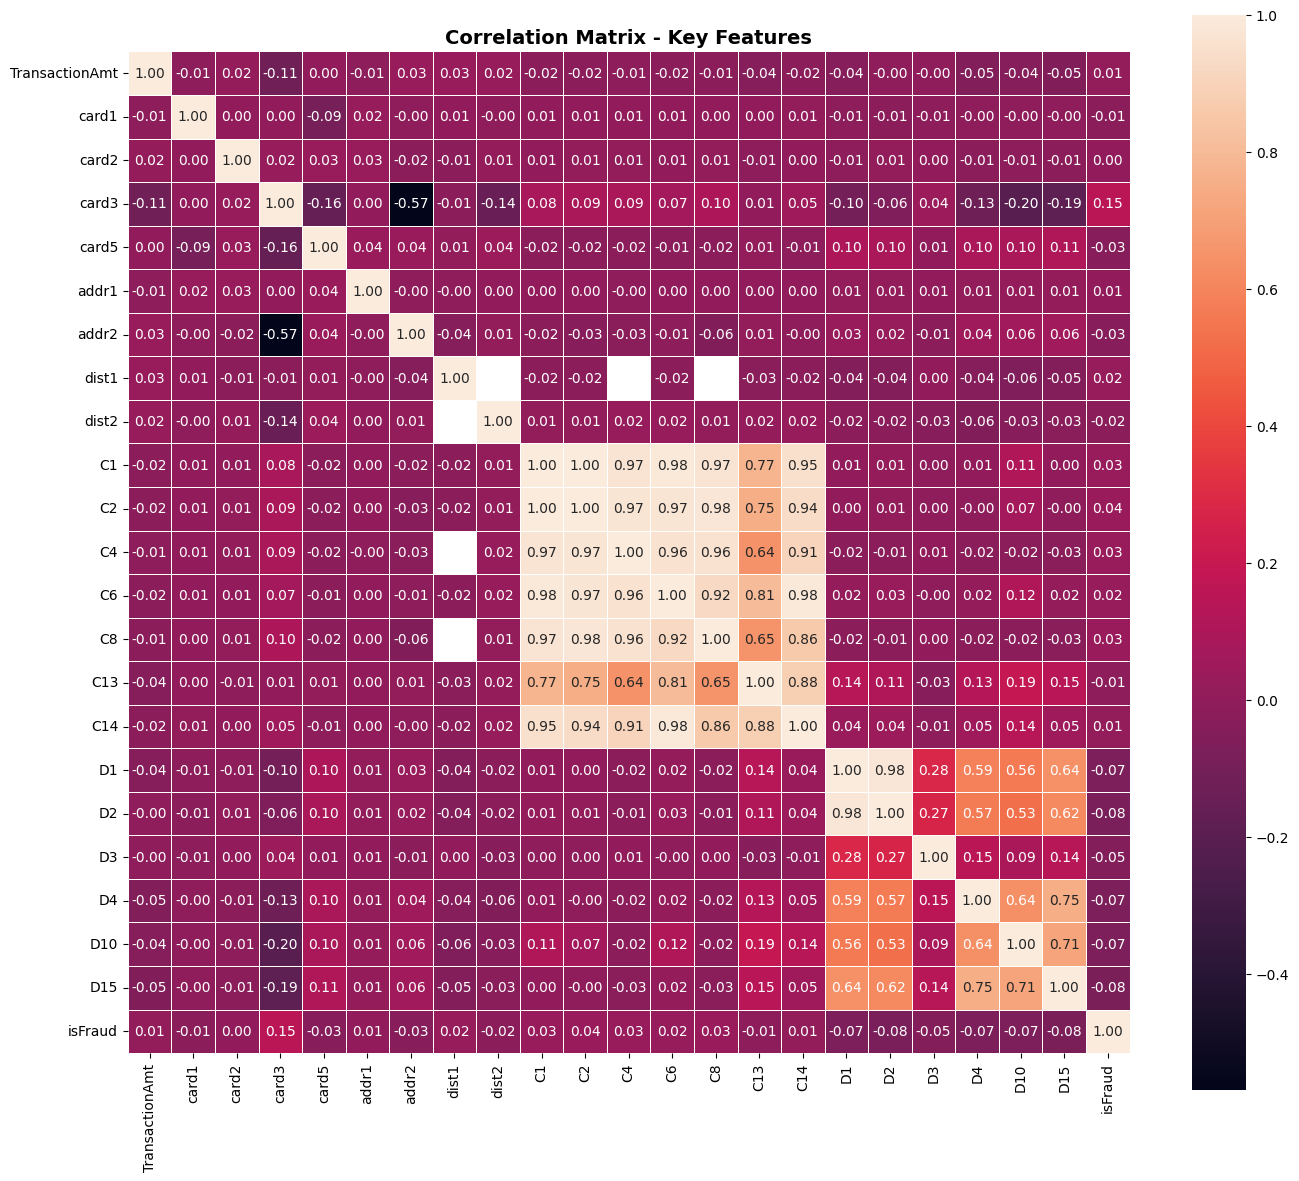


Top 15 Correlations with Fraud


,isFraud
isFraud,1.000000
card3,0.154151
D2,0.083583
D15,0.077519
D10,0.072002
D4,0.067216
D1,0.067193
D3,0.046271
C2,0.037229
card5,0.033580


In [ ]:
# Selecting important numerical fetures excluding V Features
important_num_features = ['TransactionAmt', 'card1', 'card2', 'card3', 'card5', 'addr1',
                          'addr2', 'dist1', 'dist2', 'C1', 'C2', 'C4', 'C6', 'C8', 'C13',
                          'C14', 'D1', 'D2', 'D3', 'D4', 'D10', 'D15', 'isFraud']

# Correlation Heatmap
corr_matrix = transaction_data[important_num_features].corr()

plt.figure(figsize=(14,12))
sns.heatmap(corr_matrix, annot = True, fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Matrix - Key Features', )
plt.tight_layout()
plt.show()

fraud_corr = corr_matrix['isFraud'].abs().sort_values(ascending=False)
print(f'\nTop 15 Correlations with Fraud')
fraud_corr.head(15)

## Key findings for feature engineering

Things I want to use when building features:
- **Time of day matters**: fraud spikes 7-9 AM. Worth creating hour-of-day and business-hours flags.
- **Product C is high-risk**: 11.7% fraud vs 2% for product W. ProductCD should be a strong predictor.
- **Email domains**: outlook.com and hotmail.com show up more in fraud. Could create a "common provider" flag and an "email domain match" feature (P_emaildomain == R_emaildomain).
- **Amount alone is weak**: distributions overlap too much. But maybe log-transform + "is round amount" could help extract subtle patterns.
- **No single feature is enough**: correlations with isFraud are all pretty low individually. Need to combine multiple signals.
- **Missing data is informative**: for tree models, missingness itself might be a signal (maybe fraudsters don't fill in optional fields). Will try filling with -999 to preserve this pattern rather than imputing with mean/median.